# 04 · SVM lineal
**Responsable:** Gloria Chushig

La lógica del modelo está en `src/models/linear_svm.py` → función `construir_clasificador()`.
Este notebook solo entrena, evalúa, analiza y exporta usando el flujo común
(misma partición, mismo preprocesamiento y mismas métricas que los otros modelos).

**Ejecución paso a paso:** selecciona un kernel Python de Linux (WSL2 o Colab),
abre el proyecto y ejecuta las celdas de arriba hacia abajo. En Colab, sube o clona
la carpeta del proyecto, incluyendo `src/` y `data/Dataset.csv`, instala las
dependencias de `requirements.txt` y usa `%cd` para entrar en `Detector-Phishing-ML`.
Las interpretaciones se calculan con `metricas` de esta ejecución; no toman cifras
del archivo histórico. La última etapa reentrena y reemplaza `models/modelo_svm.pkl`.

In [1]:
# Configuración: permite importar el código común de src/ desde la carpeta notebooks/
import sys
from pathlib import Path

candidatas = [Path.cwd(), Path.cwd().parent, Path.cwd() / "Detector-Phishing-ML"]
RAIZ = next((ruta for ruta in candidatas if (ruta / "src" / "config.py").exists()), None)
if RAIZ is None:
    raise FileNotFoundError("Entra en la carpeta Detector-Phishing-ML antes de ejecutar.")
if sys.platform != "linux":
    raise RuntimeError("Selecciona un kernel Linux (WSL2 o Colab) por el bloqueo de DLL en Windows.")
sys.path.insert(0, str(RAIZ))

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.simplefilter("default")
plt.style.use("ggplot")
sns.set_palette("muted")

from src import config, data, evaluation
from src.training import entrenar_y_evaluar, exportar_final

CLAVE = "svm"
from IPython.display import Markdown, display


## 1. Datos

In [2]:
df = data.cargar_dataset()
print("Filas y columnas:", df.shape)
print("Distribución de clases (0 = benigna, 1 = phishing):")
display(df[config.COLUMNA_OBJETIVO].value_counts().sort_index().rename("URLs"))
print("Número de variables:", len(data.obtener_features(df)))

Filas y columnas: (116600, 26)
Distribución de clases (0 = benigna, 1 = phishing):


label
0    100000
1     16600
Name: URLs, dtype: int64

Número de variables: 22


## 2. Entrenamiento (80%) y evaluación (20%)

In [3]:
pipeline, metricas, (X_test, y_test) = entrenar_y_evaluar(CLAVE, df)
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['url_len','dom_len','is_ip',...,'entropy','path_len','query_len']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns

In [4]:
print(metricas["reporte"])
print({k: round(metricas[k], 4) for k in ("accuracy", "precision", "recall", "f1", "auc")})

              precision    recall  f1-score   support

 Benigna (0)       0.96      0.99      0.97     20000
Phishing (1)       0.90      0.76      0.82      3320

    accuracy                           0.95     23320
   macro avg       0.93      0.87      0.90     23320
weighted avg       0.95      0.95      0.95     23320

{'accuracy': 0.9539, 'precision': 0.9027, 'recall': 0.7575, 'f1': 0.8238, 'auc': 0.9769}


## 3. Matriz de confusión

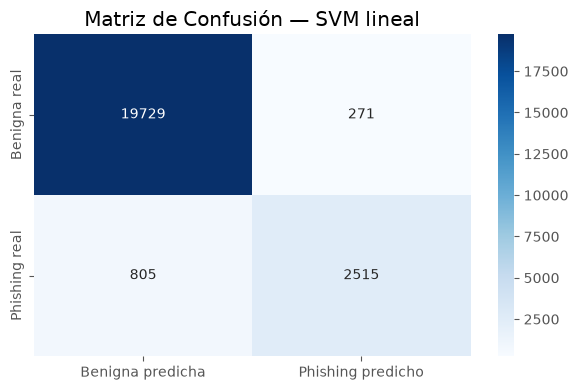

In [5]:
evaluation.graficar_matriz_confusion(metricas, f"Matriz de Confusión — {metricas['modelo']}")
plt.show()

In [6]:
tn, fp, fn, tp = np.asarray(metricas["matriz_confusion"]).ravel()
display(Markdown(
    f"**Interpretación de la matriz `[[TN, FP], [FN, TP]]`:** el SVM detectó "
    f"**{tp:,} URLs phishing (TP)**, marcó por error **{fp:,} URLs benignas (FP)** "
    f"y dejó pasar **{fn:,} URLs phishing (FN)**. Clasificó correctamente "
    f"{tn:,} URLs benignas (TN). Detectó el **{tp / (tp + fn):.2%}** del phishing "
    f"real y dejó pasar el **{fn / (tp + fn):.2%}**. Los falsos negativos son "
    "especialmente relevantes porque una URL peligrosa puede aparecer como benigna."
))

**Interpretación de la matriz `[[TN, FP], [FN, TP]]`:** el SVM detectó **2,515 URLs phishing (TP)**, marcó por error **271 URLs benignas (FP)** y dejó pasar **805 URLs phishing (FN)**. Clasificó correctamente 19,729 URLs benignas (TN). Detectó el **75.75%** del phishing real y dejó pasar el **24.25%**. Los falsos negativos son especialmente relevantes porque una URL peligrosa puede aparecer como benigna.

## 4. Curva ROC

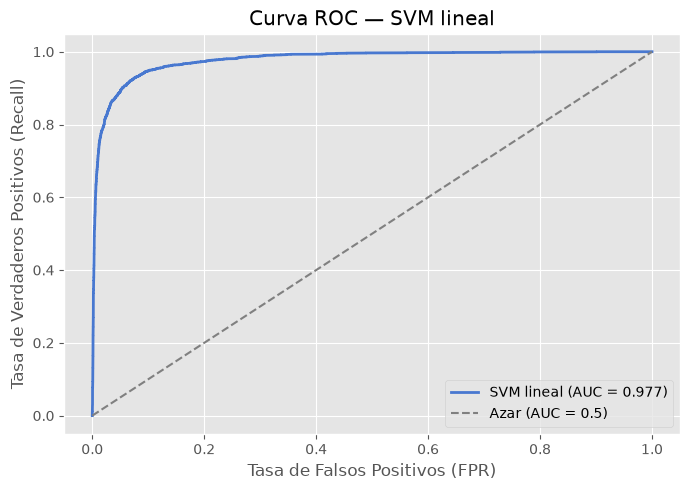

**Interpretación ROC:** el AUC obtenido es **0.9769**. La curva relaciona el recall de phishing con la tasa de falsas alarmas al variar el umbral. Un AUC próximo a 1 indica buena capacidad para ordenar phishing por encima de URLs benignas; no garantiza un recall alto en el umbral actual de **0.5**. En ese punto, el recall es **75.75%** y la tasa de falsos positivos es **1.35%**.

In [7]:
evaluation.graficar_roc({metricas["modelo"]: pipeline}, X_test, y_test, f"Curva ROC — {metricas['modelo']}")
plt.show()
display(Markdown(
    f"**Interpretación ROC:** el AUC obtenido es **{metricas['auc']:.4f}**. "
    "La curva relaciona el recall de phishing con la tasa de falsas alarmas al "
    "variar el umbral. Un AUC próximo a 1 indica buena capacidad para ordenar "
    "phishing por encima de URLs benignas; no garantiza un recall alto en el "
    f"umbral actual de **{config.UMBRAL_PHISHING}**. En ese punto, el recall es "
    f"**{metricas['recall']:.2%}** y la tasa de falsos positivos es "
    f"**{fp / (tn + fp):.2%}**."
))

## 5. Análisis específico del modelo

El SVM usa variables escaladas, `C=1.0`, `class_weight="balanced"` y calibración
sigmoide con cinco particiones. **C** controla cuánto se penalizan los errores:
un valor menor favorece mayor regularización; uno mayor penaliza más los errores
de entrenamiento y puede aumentar el sobreajuste. No se ha comparado una serie
de valores de C, por lo que no podemos afirmar que 1.0 sea el óptimo.

La ponderación balanceada asigna a cada clase un peso inverso a su frecuencia
(`n / (2 * n_clase)`). Así, los errores de la clase minoritaria pesan más en el
ajuste del hiperplano. Esto busca favorecer su detección, pero no garantiza
un aumento del recall tras calibrar y aplicar el umbral 0.5. Para medir su efecto
habría que compararla con un modelo sin ponderación usando validación dentro
del conjunto de entrenamiento, conservando el test para la evaluación final.

In [8]:
modelo = pipeline.named_steps["modelo"]
# Los parámetros pertenecen al LinearSVC dentro del calibrador.
parametros = modelo.estimator.get_params()
display(pd.Series({k: parametros[k] for k in
                   ("C", "class_weight", "max_iter", "random_state")}, name="Configuración"))
X_train, _, y_train, _ = data.dividir(df)
frecuencias = y_train.value_counts().sort_index()
resumen = pd.DataFrame({"URLs de entrenamiento": frecuencias,
                        "Peso balanceado": len(y_train) / (2 * frecuencias)})
display(resumen)
display(Markdown(
    f"Con esta configuración, el recall de phishing es **{metricas['recall']:.2%}** "
    f"y la precisión es **{metricas['precision']:.2%}**. Estos resultados describen "
    "el modelo evaluado; por sí solos no demuestran el efecto causal de C o de "
    "la ponderación. Si aparecen avisos de convergencia, revisa el ajuste antes "
    "de considerar definitivo el modelo."
))

C                    1.0
class_weight    balanced
max_iter            5000
random_state          42
Name: Configuración, dtype: object

,URLs de entrenamiento,Peso balanceado
label,,
0,80000,0.583000
1,13280,3.512048


Con esta configuración, el recall de phishing es **75.75%** y la precisión es **90.27%**. Estos resultados describen el modelo evaluado; por sí solos no demuestran el efecto causal de C o de la ponderación. Si aparecen avisos de convergencia, revisa el ajuste antes de considerar definitivo el modelo.

## 6. Exportación (reentrenado con el 100% de los datos)

La siguiente celda entrena un nuevo pipeline con todos los datos y guarda el modelo
para la aplicación. Las métricas anteriores corresponden al test del modelo
entrenado con el 80%; no son una evaluación independiente del modelo exportado.

In [9]:
ruta = exportar_final(CLAVE, df)
print("Modelo exportado en:", ruta)

Modelo exportado en: /app/models/modelo_svm.pkl


## 7. Conclusiones

La siguiente celda resume los resultados reales de esta ejecución.

In [10]:
display(Markdown(
    f"El SVM lineal alcanzó accuracy **{metricas['accuracy']:.2%}**, "
    f"precisión de phishing **{metricas['precision']:.2%}**, recall "
    f"**{metricas['recall']:.2%}**, F1 **{metricas['f1']:.4f}** y AUC "
    f"**{metricas['auc']:.4f}**. Detectó **{tp:,}** URLs phishing y dejó pasar "
    f"**{fn:,}**; produjo **{fp:,}** falsas alarmas. "
    "Para un detector de phishing, el recall merece especial atención: los "
    "falsos negativos dejan amenazas sin detectar. La precisión permite valorar "
    "qué proporción de las alertas es correcta, mientras el AUC describe la "
    "discriminación a través de distintos umbrales. La accuracy sola puede "
    "ocultar errores en la clase minoritaria. Antes de utilizar el modelo como "
    "única protección, conviene valorar si los phishing omitidos son aceptables "
    "para el uso previsto. Como mejora, se pueden comparar C y ponderaciones, "
    "y elegir un umbral que priorice recall sin generar demasiadas falsas "
    "alarmas, usando validación en entrenamiento y una evaluación final "
    "independiente."
))

El SVM lineal alcanzó accuracy **95.39%**, precisión de phishing **90.27%**, recall **75.75%**, F1 **0.8238** y AUC **0.9769**. Detectó **2,515** URLs phishing y dejó pasar **805**; produjo **271** falsas alarmas. Para un detector de phishing, el recall merece especial atención: los falsos negativos dejan amenazas sin detectar. La precisión permite valorar qué proporción de las alertas es correcta, mientras el AUC describe la discriminación a través de distintos umbrales. La accuracy sola puede ocultar errores en la clase minoritaria. Antes de utilizar el modelo como única protección, conviene valorar si los phishing omitidos son aceptables para el uso previsto. Como mejora, se pueden comparar C y ponderaciones, y elegir un umbral que priorice recall sin generar demasiadas falsas alarmas, usando validación en entrenamiento y una evaluación final independiente.